# Data Project

> **Note:** 
> 1. This is a starting point for how to structure your data project 
> 1. The `dataproject.py` file includes functions which can be in this notebook

> Initial imports and setting magics:

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import dataproject

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Part 1: Inequality in Denmark

> Loading data from Statistics Denmark's tables IFOR41 and IFOR32:

In [34]:
#data = dataproject.load_data()

# Downloading tables data
from dstapi import DstApi

# IFOR41 setup
ifor41_api = DstApi('IFOR41')

params_41 = {
    'table': 'ifor41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'TID', 'values': ['*']}
    ]
}

ifor41 = ifor41_api.get_data(params=params_41)

ifor41_df = pd.DataFrame(ifor41)
# Sorting by year
ifor41_df['INDHOLD'] = ifor41_df['INDHOLD'].astype(float)
ifor41_df['TID'] = pd.to_numeric(ifor41_df['TID'])
ifor41_df = ifor41_df.sort_values(by='TID').reset_index(drop=True)

ifor41_df.head()

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,1987,22.07
1,Gini coefficient,All Denmark,1988,22.06
2,Gini coefficient,All Denmark,1989,21.93
3,Gini coefficient,All Denmark,1990,22.16
4,Gini coefficient,All Denmark,1991,21.99


In [110]:
#IFOR32 setup
ifor32_api = DstApi('IFOR32')

params_32 = {
    'table': 'ifor32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'TID', 'values': ['*']}
    ]
}

ifor32 = ifor32_api.get_data(params=params_32)

ifor32_df = pd.DataFrame(ifor32)
# Sorting
ifor32_df['INDHOLD'] = ifor32_df['INDHOLD'].astype(float)
ifor32_df['TID'] = pd.to_numeric(ifor32_df['TID'])
ifor32_df = ifor32_df.sort_values(by=['TID']).reset_index(drop=True)

ifor32_df.head()

,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,First decil,All Denmark,1987,31418.0
1,Ninth decil,All Denmark,1987,123582.0
2,Eigth decil,All Denmark,1987,110184.0
3,Seventh decil,All Denmark,1987,100691.0
4,Sixth decil,All Denmark,1987,92777.0


> 1.1: The Gini coefficient and the top 10 percent share

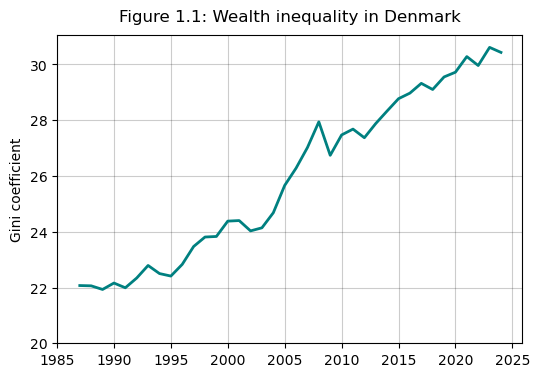

In [162]:
# Plotting figure from DataFrame ifor41_df
fig_41 = plt.figure(
    figsize=(6,4),
    facecolor='white',
)
ax_41 = fig_41.add_subplot(1,1,1)

ax_41.plot(ifor41_df['TID'], ifor41_df['INDHOLD'], label='GINI', linestyle='-', linewidth='2', color='teal', zorder=10)
ax_41.set_xticks(np.arange(1985,2025+1,5))
ax_41.set_yticks(np.arange(20, 32, 2))

ax_41.grid(True, color='black', alpha=0.2)
ax_41.set_title('Figure 1.1: Wealth inequality in Denmark', pad=10)
ax_41.set_ylabel('Gini coefficient')
plt.show()

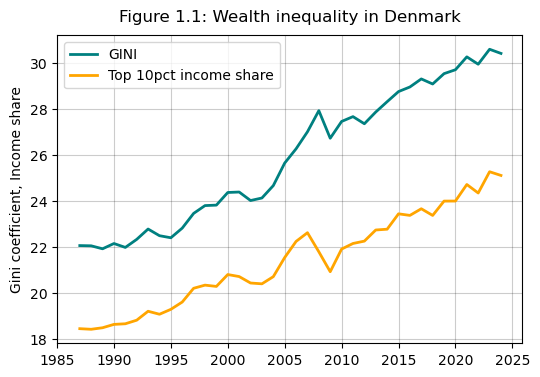

In [174]:
# Using table IFOR32, add the share of total income going to the richest 10 percent.
# Hint II: IFOR32 reports the average income within each decile group. Since every 
# decile group contains the same number of people, the income share of the top decile is:

# Calculate total avg income every year
total_decile_list = []
for decile in range(0, len(ifor32_df['INDHOLD']), 10):
    sumdecile = sum(ifor32_df['INDHOLD'][decile:decile + 10])
    total_decile_list.append(sumdecile)

# getting np.array of tenth decile
finding_10thdecile = np.where(np.array(ifor32_df[['DECILGEN']]=='Tenth decil'))
#copied from printing above
placement_10thdecile = np.array([  9,  12,  28,  30,  46,  58,  64,  70,  89,  90, 102, 118, 121,
       138, 149, 151, 162, 171, 180, 198, 202, 218, 222, 232, 243, 252,
       260, 271, 287, 298, 307, 314, 323, 330, 340, 354, 366, 378])

tenth_deciles_df = ifor32_df.iloc[placement_10thdecile]

tenth_deciles_nocommas = np.array(tenth_deciles_df['INDHOLD'])
tenth_deciles = np.array([169598, 178357, 188967, 197793, 207208, 215250, 226495, 240502, 253941,
 267669, 286696, 300898, 308395, 329207, 338942, 347627, 356782, 383943,
 416199, 447312, 466484, 446011, 437019, 500012, 516944, 533189, 560961,
 573866, 607665, 615554, 641188, 648231, 688377, 719999, 779827, 769052,
 834074, 852980,])

total_decile = np.array(total_decile_list)

incomeshare_top10 = tenth_deciles / total_decile

# Add results to figure 1.1
fig_32 = plt.figure(
    figsize=(6,4),
    facecolor='white',
)
ax_32 = fig_32.add_subplot(1,1,1)

ax_32.plot(ifor41_df['TID'], ifor41_df['INDHOLD'], label='GINI', linestyle='-', linewidth='2', color='teal', zorder=10)
ax_32.plot(ifor41_df['TID'], incomeshare_top10*100, label='Top 10pct income share', linestyle='-', linewidth='2', color='orange', zorder=5)
ax_32.set_xticks(np.arange(1985,2025+1,5))
ax_32.set_yticks(np.arange(18, 32, 2))

ax_32.grid(True, color='black', alpha=0.2)
ax_32.set_title('Figure 1.1: Wealth inequality in Denmark', pad=10)
ax_32.set_ylabel('Gini coefficient, Income share')

ax_32.legend()
plt.show()

In [198]:
# Describe how inequality in Denmark has developed since 1987. Do the two measures 
# tell the same story? Compute the correlation between them over time.
# Hint III: pd.merge(...,validate=’1:1’) is a cheap way to check that you have not accidentally duplicated rows.

# Correlation
correlation = ifor41_df['INDHOLD'].corr(tenth_deciles_df['INDHOLD'])
print('Correlation is: ' + str(correlation))

Correlation is: 0.9572540180507504


<p> Both the Gini coefficient and the richest 10 percent's income share have <br>
increased a relatively great amount (almost a 10 percent-point increase in both) </p>

<p> Based on the final figure 1.1 and above calculated correlation, <br>
it appears to be the case that the Gini coefficient and <br>
the richest 10 percent's income share are highly correlated (almost 1:1).</p>

<p> They both signify an increase in the wealth distribution between the Danes, <br>
with the Gini coefficient showing a general decrease in equal distribution between the <br>
ten deciles of the population, where the increase in the 10 percent richest people's income share <br>
may have played a significant part. Especially when taking the correlation between the two <br>
into account.</p>

> 1.2: Prediction

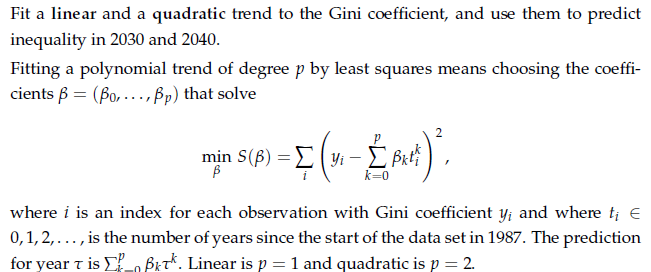

In [39]:
# 1. Solve this minimization problem yourself with scipy.optimize.minimize.

In [40]:
# 2. Check your answer against np.polyfit. Do you get the same coefficients?

In [41]:
# 3. Use your estimates to predict the Gini coefficient in 2030 and 2040, and plot the result.

In [42]:
# How well do the two specifications fit the historical data? How much do their predictions
# differ? Would you trust either of them, and why?

> 1.3: Municipalities

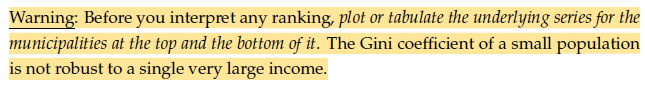

In [43]:
# Both tables are also available at the municipality level. Do the following:
# 1. Compute the correlation between the Gini coefficient and the top 10 percent
# share across municipalities. Is it similar to the correlation over time you found above?

In [44]:
#2. Find the 10 most and the 10 least unequal municipalities in the most recent 
# year, and illustrate them in a figure. Describe the pattern.

In [45]:
# 3. Find the municipalities with the largest and the smallest change in the Gini coefficient. Illustrate and comment.

> 1.4: Extension

In [46]:
# Find some other information at the municipality level and relate it to the level of the
# Gini coefficient or to its change over time.
# Note: This is intended as an open question, and we encourage you to be creative.

### Part 2: Simulating the income distribution

> TO BE WRITTEN

In [47]:
#data = dataproject.process_data(data)

In [48]:
#fig = plt.figure(figsize=(7,4))
#ax = fig.add_subplot(111)

#ax.plot(data['log_GDP'],label='log(GDP)')

#ax.set_title('Log GDP over time')
#ax.set_xlabel('Year')
#ax.set_ylabel('Log GDP')

#ax.legend();

We find that that ...